<a href="https://colab.research.google.com/github/donna6355/study_python/blob/master/dl/LangChain_%E1%84%89%E1%85%B5%E1%86%AF%E1%84%89%E1%85%B3%E1%86%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔗 LangChain 완전정복 - LLM 앱 개발 프레임워크

> **"LLM을 단순히 호출하는 게 아니라, 진짜 '앱'으로 만드는 도구"**

## 🌟 이 노트북에서 배울 것

LangChain은 LLM 기반 애플리케이션을 만들기 위한 **가장 인기 있는 프레임워크**입니다.

### 📋 핵심 학습 내용

1. **왜 LangChain?** - 기본 API 호출과의 차이
2. **LCEL** - 파이프 `|` 연산자로 모듈 조합
3. **Prompts & Templates** - 프롬프트 체계적 관리
4. **Memory** - 대화 기록 자동 관리
5. **RAG (검색 증강 생성)** - 내 문서로 LLM 답변
6. **Agents & Tools** - 자율적으로 도구 사용
7. **실전 통합** - 챗봇 + RAG + Tools 결합

## 📌 이 노트북의 특징

- ✅ **LangChain v1.x (2025.10 출시)** 최신 패턴 사용
- ✅ **LCEL 중심** (모던 LangChain의 표준)
- ✅ **친근한 비유 + 풍부한 시각화**
- ✅ **단계별 예제 → 통합 예제**
- ✅ **API 키 없이도 학습 가능** (시뮬레이션 모드)
- ✅ **빈칸 채우기 실습 + 퀴즈**

> 💡 **선수 학습**: LLM API 사용법(OpenAI/Claude 등)을 알면 좋아요.
> 시리즈 8번 노트북(상업용 LLM)을 먼저 보시면 이해가 쉽습니다.

> ⚠️ **버전 주의**: LangChain은 자주 바뀝니다. 본 노트북은 **v1.x** 기준.

---

## 📚 전체 목차

| 섹션 | 제목 | 내용 |
|------|------|------|
| 1 | 🛠️ 환경 설정 | 설치 + API 키 |
| 2 | 🤔 왜 LangChain? | 기본 API와 비교 |
| 3 | 🚀 첫 LCEL Chain | 파이프로 모듈 연결 |
| 4 | 📝 Prompts & Templates | 프롬프트 체계화 |
| 5 | 📤 Output Parsers | 구조화된 출력 |
| 6 | 🔧 LCEL 고급 | 병렬·분기·조건 처리 |
| 7 | 💬 Memory | 대화 기록 관리 |
| 8 | 📄 Document Loaders & Splitters | 문서 처리 |
| 9 | 🔍 Embeddings & Vector Stores | 의미 검색 인프라 |
| 10 | 🎯 RAG (검색 증강 생성) | 내 문서로 답변 |
| 11 | 🤖 Tools & Agents | 자율 에이전트 |
| 12 | 💼 실전 통합 예제 | 챗봇 + RAG + Tools |
| 13 | ⚠️ 함정과 모범 사례 | 자주 하는 실수 |
| 14 | 🎓 최종 정리 | 다음 단계 |


---
# 1️⃣ 환경 설정 🛠️

## 📦 LangChain의 패키지 구조

LangChain v1.x부터 패키지가 **여러 개로 분리**되었어요:

| 패키지 | 역할 |
|--------|------|
| `langchain` | 메인 패키지 (chains, retrievers, agents) |
| `langchain-core` | 핵심 추상화 (Runnable, Prompt 등) |
| `langchain-community` | 커뮤니티 통합 (vector stores, loaders) |
| `langchain-openai` | OpenAI 통합 |
| `langchain-anthropic` | Claude 통합 |
| `langchain-google-genai` | Gemini 통합 |
| `langchain-text-splitters` | 텍스트 분할 |
| `langgraph` | 에이전트 워크플로우 |

### 비유: 자동차 부품
- `langchain-core` = 엔진
- `langchain-openai` = 특정 브랜드 액세서리
- `langgraph` = 자율주행 모듈

In [1]:
# 📦 LangChain 핵심 패키지 설치
!pip install -q langchain langchain-core langchain-community
!pip install -q langchain-openai langchain-anthropic
!pip install -q langchain-text-splitters
!pip install -q langgraph
!pip install -q faiss-cpu  # 가벼운 vector store

print("✅ LangChain 설치 완료!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.4/50.4 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 763.1/763.1 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 65.4 MB/s eta 0:00:00
✅ LangChain 설치 완료!


In [2]:
# 📚 기본 import
import os
import json
from typing import List, Dict, Any
import matplotlib.pyplot as plt
import numpy as np
import os
import matplotlib.font_manager as fm

# 한글 폰트 (Colab용)
!apt-get install -y fonts-nanum > /dev/null
!fc-cache -fv > /dev/null
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

print("✅ 라이브러리 준비 완료!")

✅ 라이브러리 준비 완료!


In [3]:
# 🔑 API 키 설정 (Colab Secrets 또는 환경 변수)
try:
    from google.colab import userdata

    def get_secret(key_name, default=""):
        try:
            return userdata.get(key_name)
        except Exception:
            return default
except ImportError:
    def get_secret(key_name, default=""):
        return os.environ.get(key_name, default)

OPENAI_API_KEY = get_secret('OPENAI_API_KEY', '')
ANTHROPIC_API_KEY = get_secret('ANTHROPIC_API_KEY', '')

# LangChain은 환경 변수에서 자동으로 키를 읽음
if OPENAI_API_KEY:
    os.environ['OPENAI_API_KEY'] = OPENAI_API_KEY
if ANTHROPIC_API_KEY:
    os.environ['ANTHROPIC_API_KEY'] = ANTHROPIC_API_KEY

# 상태 확인 (키 값은 출력하지 않음)
print("🔑 API 키 상태:")
print(f"   OpenAI:    {'✅ 설정됨' if OPENAI_API_KEY else '⚠️ 미설정'}")
print(f"   Anthropic: {'✅ 설정됨' if ANTHROPIC_API_KEY else '⚠️ 미설정'}")

if not OPENAI_API_KEY and not ANTHROPIC_API_KEY:
    print("\n💡 API 키 없이도 학습 가능합니다!")
    print("   시뮬레이션 모드로 동작합니다.")

🔑 API 키 상태:
   OpenAI:    ⚠️ 미설정
   Anthropic: ⚠️ 미설정

💡 API 키 없이도 학습 가능합니다!
   시뮬레이션 모드로 동작합니다.


### ✅ 체크포인트 1
환경 설정 완료! 🎉

> 💡 API 키가 없어도 코드 구조 학습 가능

---
# 2️⃣ 왜 LangChain? 🤔

## 🆚 기본 API vs LangChain

같은 작업을 두 방법으로 비교해봅시다.

### 시나리오: "주제에 대한 짧은 글 작성 → 한국어 번역"

### 방법 1: 기본 OpenAI API (LangChain 없이)

```python
# 1단계: 영어 글 생성
response1 = openai.chat.completions.create(
    model="gpt-4",
    messages=[{"role": "user", "content": "Write a 3-sentence article about AI."}]
)
english = response1.choices[0].message.content

# 2단계: 영어 → 한국어 번역
response2 = openai.chat.completions.create(
    model="gpt-4",
    messages=[{"role": "user", "content": f"Translate to Korean: {english}"}]
)
korean = response2.choices[0].message.content

print(korean)
```

### 방법 2: LangChain LCEL

```python
# 두 단계를 파이프로 연결
chain = (
    write_prompt | model | parser
    | translate_prompt | model | parser
)

result = chain.invoke({"topic": "AI"})
print(result)
```

> 💡 **LangChain은 LLM 호출을 "조립 가능한 부품"으로 만들어줘요.**

## 🏗️ LangChain의 4가지 핵심 가치

### 1️⃣ **모듈화 (Modularity)**
- 작은 부품들 (Prompt, Model, Parser) 조합
- 부품 교체 자유 (OpenAI → Claude 한 줄로!)

### 2️⃣ **재사용성 (Reusability)**
- 한 번 만든 체인을 여러 곳에서 사용
- 표준화된 인터페이스

### 3️⃣ **확장성 (Extensibility)**
- RAG, Agents 같은 고급 패턴 내장
- Vector DB, 외부 도구 통합

### 4️⃣ **추상화 (Abstraction)**
- 복잡한 작업을 단순 코드로
- 스트리밍, 비동기, 병렬 처리 자동

## 🎯 비유: 레고 블록

```
기본 API 사용:    ⬛ ⬛ ⬛  (블록을 따로 들고 직접 조립)
LangChain:        🟦🟦🟦  (블록이 서로 잘 맞물리도록 설계됨)
```

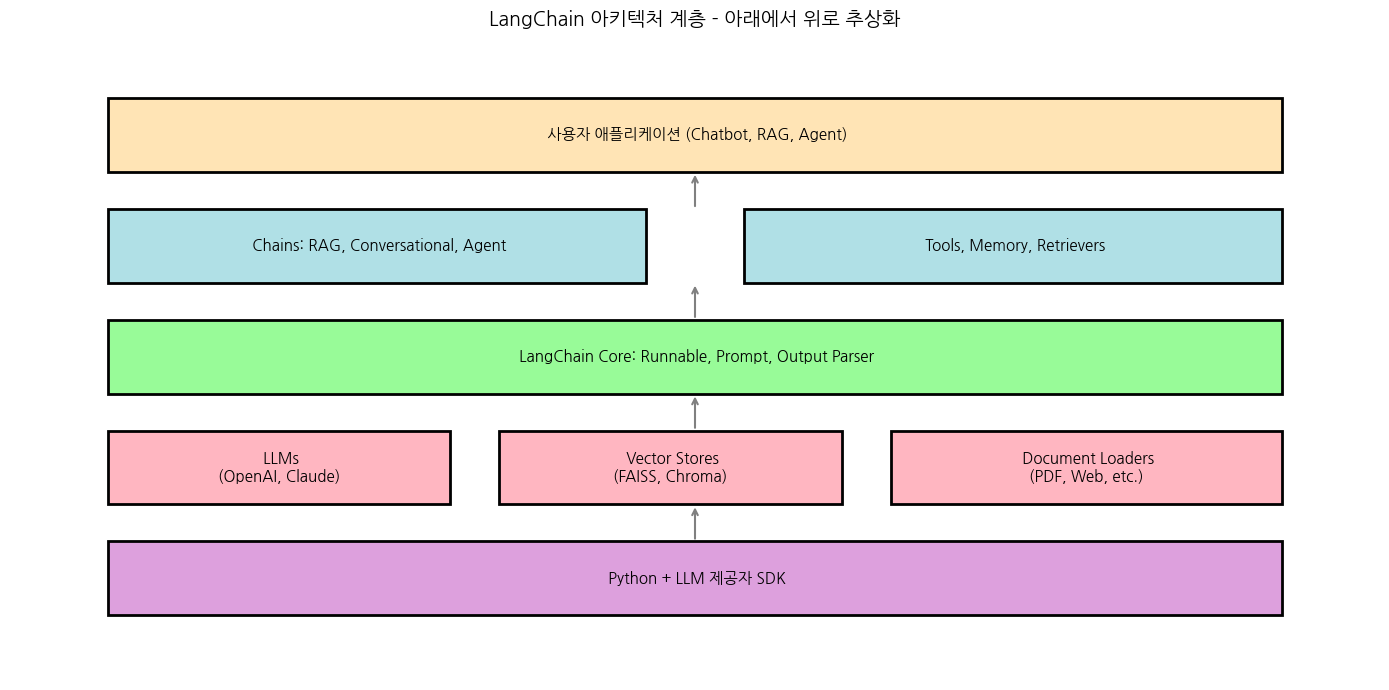


💡 사용자는 위쪽 계층만 다루면 됨
💡 아래쪽 계층은 LangChain이 알아서 처리!


In [4]:
# 🎨 LangChain의 구조 시각화
fig, ax = plt.subplots(figsize=(14, 7))

# 박스 그리기 헬퍼
def draw_layer(ax, x, y, w, h, text, color):
    ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=color,
                                 edgecolor='black', linewidth=2))
    ax.text(x + w/2, y + h/2, text, ha='center', va='center',
            fontsize=11, fontweight='bold')

# 사용자 앱 (최상위)
draw_layer(ax, 1, 6, 12, 0.8, ' 사용자 애플리케이션 (Chatbot, RAG, Agent)', '#FFE4B5')

# Use Cases (chains)
draw_layer(ax, 1, 4.8, 5.5, 0.8, ' Chains: RAG, Conversational, Agent', '#B0E0E6')
draw_layer(ax, 7.5, 4.8, 5.5, 0.8, ' Tools, Memory, Retrievers', '#B0E0E6')

# Core
draw_layer(ax, 1, 3.6, 12, 0.8, ' LangChain Core: Runnable, Prompt, Output Parser', '#98FB98')

# Integrations
draw_layer(ax, 1, 2.4, 3.5, 0.8, ' LLMs\n(OpenAI, Claude)', '#FFB6C1')
draw_layer(ax, 5, 2.4, 3.5, 0.8, ' Vector Stores\n(FAISS, Chroma)', '#FFB6C1')
draw_layer(ax, 9, 2.4, 4, 0.8, ' Document Loaders\n(PDF, Web, etc.)', '#FFB6C1')

# Base
draw_layer(ax, 1, 1.2, 12, 0.8, ' Python + LLM 제공자 SDK', '#DDA0DD')

# 화살표 (위로 흐름)
for y in [2, 3.2, 4.4, 5.6]:
    ax.annotate('', xy=(7, y+0.4), xytext=(7, y),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

ax.set_xlim(0, 14)
ax.set_ylim(0.5, 7.5)
ax.axis('off')
ax.set_title('LangChain 아키텍처 계층 - 아래에서 위로 추상화',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 사용자는 위쪽 계층만 다루면 됨")
print("💡 아래쪽 계층은 LangChain이 알아서 처리!")

---
# 3️⃣ 첫 번째 LCEL Chain 🚀

## 🌟 LCEL이란?

**L**ang**C**hain **E**xpression **L**anguage = "체인 조립 언어"

핵심 아이디어: **파이프 연산자 `|`** 로 컴포넌트 연결!

```python
chain = prompt | model | parser
result = chain.invoke({"topic": "AI"})
```

### 🔧 비유: Unix 파이프

```bash
# Unix
cat file.txt | grep "error" | sort | uniq

# LangChain
prompt | model | parser
```

데이터가 **왼쪽에서 오른쪽으로** 흐르며 각 단계 처리!

In [5]:
# 🤖 시뮬레이션을 위한 Mock LLM (API 키 없을 때 사용)
from langchain_core.language_models.fake import FakeListLLM
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langchain_core.runnables import Runnable

class MockChatModel(Runnable):
    """API 키 없을 때 사용하는 가짜 모델 - 학습용"""

    def __init__(self, name="Mock", responses=None):
        self.name = name
        self.responses = responses or [
            "이것은 시뮬레이션 응답입니다. 실제 API 키를 설정하면 진짜 응답을 받을 수 있어요.",
        ]
        self.call_count = 0

    def invoke(self, input_data, config=None, **kwargs):
        """LangChain Runnable 인터페이스"""
        response = self.responses[self.call_count % len(self.responses)]
        self.call_count += 1
        return AIMessage(content=f"[{self.name} 시뮬레이션] {response}")

    def stream(self, input_data, config=None, **kwargs):
        """스트리밍 시뮬레이션"""
        response = self.responses[self.call_count % len(self.responses)]
        self.call_count += 1
        # 한 글자씩 yield
        for char in f"[{self.name}] {response}":
            yield AIMessage(content=char)

# 실제 모델 로드 또는 mock 사용
def get_llm(model_name="gpt-4o-mini", temperature=0.7):
    """환경에 맞는 LLM 반환"""
    if OPENAI_API_KEY:
        from langchain_openai import ChatOpenAI
        return ChatOpenAI(model=model_name, temperature=temperature)
    elif ANTHROPIC_API_KEY:
        from langchain_anthropic import ChatAnthropic
        return ChatAnthropic(model="claude-haiku-4-5-20251001", temperature=temperature)
    else:
        # 시뮬레이션
        return MockChatModel(
            name="MockLLM",
            responses=[
                "인공지능(AI)은 인간의 학습·추론·문제 해결 능력을 모방하는 컴퓨터 시스템입니다.",
                "AI는 현재 의료, 금융, 교육 등 다양한 분야에서 혁신을 주도하고 있습니다.",
                "미래에 AI는 더 자율적이고 창의적인 작업을 수행할 것으로 기대됩니다.",
            ]
        )

llm = get_llm()
print(f"🤖 사용 모델: {type(llm).__name__}")

🤖 사용 모델: MockChatModel


In [6]:
# 🚀 가장 단순한 LCEL Chain
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# 1. Prompt 정의
prompt = ChatPromptTemplate.from_template(
    "당신은 친절한 AI 강사입니다. '{topic}'에 대해 2-3문장으로 설명해주세요."
)

# 2. Output Parser (응답을 깔끔한 문자열로)
parser = StrOutputParser()

# 3. 파이프로 체인 연결! (LCEL 핵심)
chain = prompt | llm | parser

# 4. 실행
result = chain.invoke({"topic": "인공지능"})

print("🚀 첫 번째 LCEL Chain 실행 결과:")
print("=" * 60)
print(result)

🚀 첫 번째 LCEL Chain 실행 결과:
[MockLLM 시뮬레이션] 인공지능(AI)은 인간의 학습·추론·문제 해결 능력을 모방하는 컴퓨터 시스템입니다.


## 🔍 LCEL Chain 동작 원리

```
입력: {"topic": "인공지능"}
    ↓ prompt가 받음
"당신은 친절한 AI 강사입니다. '인공지능'에 대해..."
    ↓ llm이 받음
AIMessage(content="인공지능은 인간의...")
    ↓ parser가 받음
"인공지능은 인간의..."
    ↓
최종 결과 (str)
```

각 컴포넌트는:
- **입력**을 받아서
- **출력**을 다음으로 넘김

이게 전부예요! 매우 단순합니다.

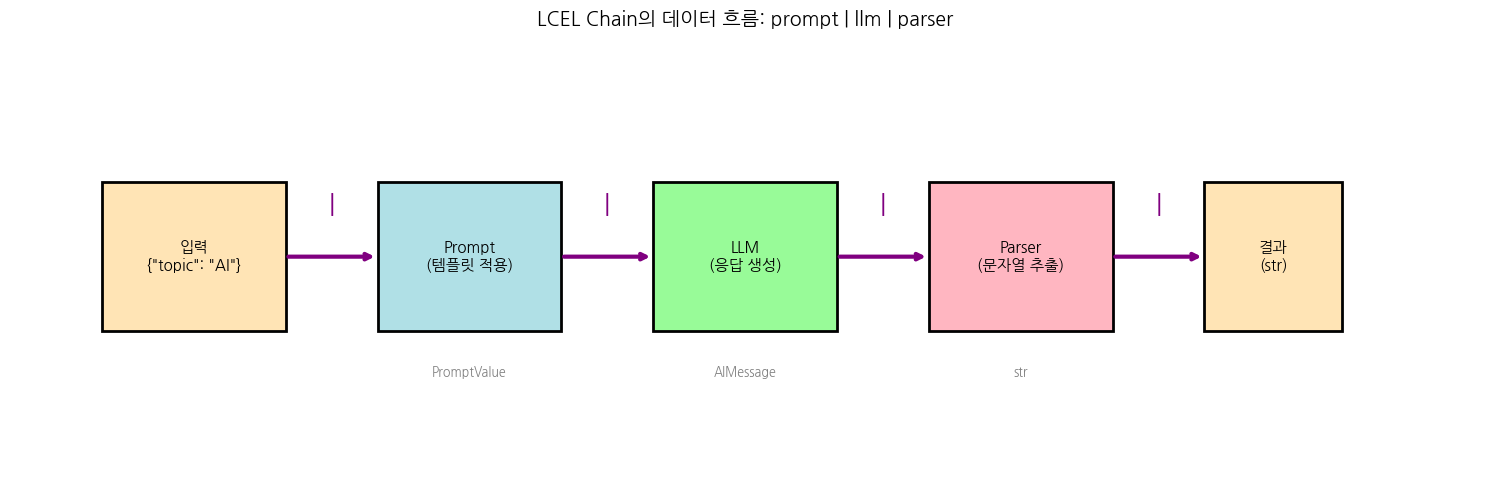


💡 각 단계의 출력 타입이 다음 단계의 입력 타입과 자동 매칭됨
💡 이게 LangChain의 '인터페이스 표준화' 가치!


In [7]:
# 🎨 LCEL Chain 동작 시각화
fig, ax = plt.subplots(figsize=(15, 5))

# 박스
boxes = [
    (1, 2.5, 2, 1, '입력\n{"topic": "AI"}', '#FFE4B5'),
    (4, 2.5, 2, 1, 'Prompt\n(템플릿 적용)', '#B0E0E6'),
    (7, 2.5, 2, 1, 'LLM\n(응답 생성)', '#98FB98'),
    (10, 2.5, 2, 1, 'Parser\n(문자열 추출)', '#FFB6C1'),
    (13, 2.5, 1.5, 1, '결과\n(str)', '#FFE4B5'),
]

for x, y, w, h, text, color in boxes:
    ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=color,
                                 edgecolor='black', linewidth=2))
    ax.text(x + w/2, y + h/2, text, ha='center', va='center',
            fontsize=11, fontweight='bold')

# 화살표 (파이프 표현)
arrow_positions = [(3, 3), (6, 3), (9, 3), (12, 3)]
arrow_ends = [(4, 3), (7, 3), (10, 3), (13, 3)]

for (xs, ys), (xe, ye) in zip(arrow_positions, arrow_ends):
    ax.annotate('', xy=(xe, ye), xytext=(xs, ys),
                arrowprops=dict(arrowstyle='->', color='purple', lw=3))
    ax.text((xs+xe)/2, ye+0.3, '|', fontsize=18, ha='center', color='purple',
            fontweight='bold')

# 데이터 흐름 라벨
labels_below = [
    (5, 2.2, 'PromptValue'),
    (8, 2.2, 'AIMessage'),
    (11, 2.2, 'str'),
]
for x, y, text in labels_below:
    ax.text(x, y, text, ha='center', fontsize=9, style='italic', color='gray')

ax.set_xlim(0, 16)
ax.set_ylim(1.5, 4.5)
ax.axis('off')
ax.set_title('LCEL Chain의 데이터 흐름: prompt | llm | parser',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 각 단계의 출력 타입이 다음 단계의 입력 타입과 자동 매칭됨")
print("💡 이게 LangChain의 '인터페이스 표준화' 가치!")

## ⚡ LCEL의 추가 능력

같은 chain 객체로 다양한 실행 모드 지원!

In [8]:
# ⚡ 다양한 실행 모드

# 1. invoke: 동기 실행 (가장 기본)
result = chain.invoke({"topic": "머신러닝"})
print("1️⃣ invoke (동기):")
print(f"   {result[:100]}...")
print()

# 2. batch: 여러 입력 한 번에 처리 (병렬)
topics = ["딥러닝", "강화학습", "자연어처리"]
results = chain.batch([{"topic": t} for t in topics])
print("2️⃣ batch (여러 입력 병렬 처리):")
for topic, result in zip(topics, results):
    print(f"   [{topic}] {result[:80]}...")
print()

# 3. stream: 스트리밍 (글자가 하나씩 출력)
print("3️⃣ stream (실시간 스트리밍):")
print("   ", end='')
for chunk in chain.stream({"topic": "생성형 AI"}):
    print(chunk, end='', flush=True)
print("\n")

print("💡 같은 chain, 다른 실행 모드 → 코드 변경 없이!")

1️⃣ invoke (동기):
   [MockLLM 시뮬레이션] AI는 현재 의료, 금융, 교육 등 다양한 분야에서 혁신을 주도하고 있습니다....

2️⃣ batch (여러 입력 병렬 처리):
   [딥러닝] [MockLLM 시뮬레이션] 미래에 AI는 더 자율적이고 창의적인 작업을 수행할 것으로 기대됩니다....
   [강화학습] [MockLLM 시뮬레이션] 인공지능(AI)은 인간의 학습·추론·문제 해결 능력을 모방하는 컴퓨터 시스템입니다....
   [자연어처리] [MockLLM 시뮬레이션] AI는 현재 의료, 금융, 교육 등 다양한 분야에서 혁신을 주도하고 있습니다....

3️⃣ stream (실시간 스트리밍):
   [MockLLM] 미래에 AI는 더 자율적이고 창의적인 작업을 수행할 것으로 기대됩니다.

💡 같은 chain, 다른 실행 모드 → 코드 변경 없이!


## 🎯 빈칸 채우기 실습 #1

여러분만의 첫 LCEL Chain을 만들어보세요!

In [9]:
# 🎯 실습 #1: 시 짓는 LCEL Chain
# 주어진 주제로 짧은 한국어 시를 짓는 체인

# TODO: 1. ChatPromptTemplate으로 prompt 만들기
poetry_prompt = ChatPromptTemplate.from_template(
    "당신은 한국어 시인입니다. '{subject}'에 대해 짧은 시(4행 이내)를 써주세요."
)

# TODO: 2. parser 만들기 (StrOutputParser 사용)
poetry_parser = StrOutputParser()

# TODO: 3. 파이프로 체인 연결 (prompt | llm | parser 순서!)
poetry_chain = poetry_prompt | llm | poetry_parser

# TODO: 4. invoke로 실행
result = poetry_chain.invoke({"subject": "벚꽃"})

print("🌸 생성된 시:")
print(result)

🌸 생성된 시:
[MockLLM 시뮬레이션] 인공지능(AI)은 인간의 학습·추론·문제 해결 능력을 모방하는 컴퓨터 시스템입니다.


<details>
<summary>🔑 정답 보기</summary>

```python
poetry_parser = StrOutputParser()
poetry_chain = poetry_prompt | llm | poetry_parser
result = poetry_chain.invoke({"subject": "벚꽃"})
```

LCEL의 핵심:
- `prompt | model | parser` 순서
- `.invoke()` 메서드로 실행
- 입력은 `dict` 형식 (템플릿 변수에 매핑)

</details>

## 🧠 퀴즈 #1

LCEL의 파이프 연산자 `|`의 역할은?

- A) 두 함수의 결과를 더하기
- B) **앞 컴포넌트의 출력을 뒤 컴포넌트의 입력으로 전달**
- C) 에러를 무시하기
- D) Python 비트 연산

<details>
<summary>👉 정답 보기</summary>

**B) 앞 컴포넌트의 출력을 뒤 컴포넌트의 입력으로 전달**

LCEL의 `|`는:
- Python의 `__or__` 메서드를 활용
- `prompt.__or__(llm)` 처럼 동작
- 각 컴포넌트가 `Runnable`을 상속해서 가능
- Unix 파이프와 비슷한 데이터 흐름

</details>

### ✅ 체크포인트 2 - LCEL 첫 걸음!

🎉 LangChain의 기본 학습 완료! 배운 것:
- **LangChain의 가치**: 모듈화·재사용성·확장성
- **LCEL 기본 구조**: `prompt | model | parser`
- **실행 모드**: invoke, batch, stream
- **데이터 흐름**: dict → PromptValue → AIMessage → str

다음은 **Prompts 깊이 학습**! 📝

---
# 4️⃣ Prompts & Templates 📝

## 🎯 왜 프롬프트 템플릿?

매번 프롬프트를 직접 작성하면 안 좋아요:

### ❌ 나쁜 방법
```python
prompt1 = f"Translate '{text}' to Korean."
prompt2 = f"Translate '{another_text}' to Korean."
# 매번 f-string으로 직접 만들기 → 관리 어려움
```

### ✅ LangChain 방법
```python
template = ChatPromptTemplate.from_template("Translate '{text}' to Korean.")
result1 = template.invoke({"text": "Hello"})
result2 = template.invoke({"text": "Goodbye"})
# 재사용 가능 + 변수 검증 + 디버깅 쉬움
```

## 📋 3가지 주요 Template 타입

In [10]:
# 1️⃣ PromptTemplate - 단순 텍스트
from langchain_core.prompts import PromptTemplate

template = PromptTemplate.from_template(
    "다음 문장을 {language}로 번역해주세요: {text}"
)

# 변수 채워 넣기
formatted = template.invoke({
    "language": "프랑스어",
    "text": "안녕하세요"
})

print("1️⃣ PromptTemplate 예시:")
print(formatted.to_string())
print()

# 변수 확인
print(f"📋 필요한 변수들: {template.input_variables}")

1️⃣ PromptTemplate 예시:
다음 문장을 프랑스어로 번역해주세요: 안녕하세요

📋 필요한 변수들: ['language', 'text']


In [11]:
# 2️⃣ ChatPromptTemplate - 채팅 형식 (가장 많이 사용)
from langchain_core.prompts import ChatPromptTemplate

chat_template = ChatPromptTemplate.from_messages([
    ("system", "당신은 {role}입니다. {style} 스타일로 답하세요."),
    ("human", "{question}"),
])

# 변수 채우기
formatted = chat_template.invoke({
    "role": "친절한 한국어 강사",
    "style": "예시를 많이 들어 자세하게",
    "question": "조사 '은/는'과 '이/가'의 차이는?"
})

print("2️⃣ ChatPromptTemplate 예시:")
for msg in formatted.to_messages():
    print(f"   [{msg.type}] {msg.content}")
print()

# 체인과 함께 사용
chain = chat_template | llm | StrOutputParser()
result = chain.invoke({
    "role": "친절한 한국어 강사",
    "style": "예시를 많이 들어 자세하게",
    "question": "조사 '은/는'과 '이/가'의 차이는?"
})
print("✨ LLM 응답:")
print(result[:400])

2️⃣ ChatPromptTemplate 예시:
   [system] 당신은 친절한 한국어 강사입니다. 예시를 많이 들어 자세하게 스타일로 답하세요.
   [human] 조사 '은/는'과 '이/가'의 차이는?

✨ LLM 응답:
[MockLLM 시뮬레이션] AI는 현재 의료, 금융, 교육 등 다양한 분야에서 혁신을 주도하고 있습니다.


In [ ]:
# 3️⃣ Few-shot Prompt - 예시 기반 학습
from langchain_core.prompts import FewShotPromptTemplate, PromptTemplate

# 예시 정의
examples = [
    {"input": "행복하다", "output": "긍정"},
    {"input": "슬프다", "output": "부정"},
    {"input": "그저 그렇다", "output": "중립"},
    {"input": "환상적이다", "output": "긍정"},
]

# 각 예시의 포맷
example_template = PromptTemplate.from_template(
    "단어: {input}\n감정: {output}"
)

# Few-shot 프롬프트 구성
fewshot_prompt = FewShotPromptTemplate(
    examples=examples,
    example_prompt=example_template,
    prefix="다음 단어의 감정을 긍정/부정/중립 중에서 분류하세요.\n예시:",
    suffix="\n단어: {input}\n감정:",
    input_variables=["input"]
)

# 사용해보기
formatted = fewshot_prompt.invoke({"input": "감격스럽다"})
print("3️⃣ Few-shot Prompt 예시:")
print("=" * 50)
print(formatted.to_string())

## 🆚 Few-shot의 효과

같은 작업, 다른 프롬프트 비교:

| 방법 | 정확도 | 일관성 |
|------|--------|--------|
| 그냥 묻기 | 70% | 들쭉날쭉 |
| Few-shot (예시 3~5개) | **90%+** | **일관됨** |

> 💡 LLM은 **예시를 보면 패턴을 빠르게 학습**해요!

In [12]:
# 🎨 MessagesPlaceholder - 동적 메시지 삽입
from langchain_core.prompts import MessagesPlaceholder

# 대화 기록을 받을 수 있는 템플릿
chat_with_history = ChatPromptTemplate.from_messages([
    ("system", "당신은 친절한 AI 어시스턴트입니다."),
    MessagesPlaceholder(variable_name="chat_history"),  # 이전 대화 자동 삽입
    ("human", "{question}"),
])

# 가상의 대화 기록
from langchain_core.messages import HumanMessage, AIMessage

history = [
    HumanMessage(content="안녕! 내 이름은 김민수야"),
    AIMessage(content="안녕하세요 김민수님! 반갑습니다."),
]

# 변수 + history 동시 전달
formatted = chat_with_history.invoke({
    "chat_history": history,
    "question": "내 이름이 뭐였지?"
})

print("💬 대화 기록이 포함된 프롬프트:")
for msg in formatted.to_messages():
    print(f"   [{msg.type}] {msg.content}")

print("\n💡 이 패턴이 챗봇 메모리의 기반!")

💬 대화 기록이 포함된 프롬프트:
   [system] 당신은 친절한 AI 어시스턴트입니다.
   [human] 안녕! 내 이름은 김민수야
   [ai] 안녕하세요 김민수님! 반갑습니다.
   [human] 내 이름이 뭐였지?

💡 이 패턴이 챗봇 메모리의 기반!


---
# 5️⃣ Output Parsers 📤

## 🎯 왜 Output Parser?

LLM의 응답은 **자유로운 자연어**입니다. 하지만 우리 앱은 **구조화된 데이터**가 필요해요!

### 비유: 면접

```
면접관 질문: "스스로를 소개해주세요"

응답 1 (자유): "안녕하세요, 저는 김민수이고 28살이며..."
응답 2 (구조화): {"name": "김민수", "age": 28, "skills": ["Python", "AI"]}
```

앱은 **응답 2**가 훨씬 다루기 쉬워요!

## 📋 주요 Output Parser 종류

| Parser | 출력 형식 | 용도 |
|--------|---------|------|
| `StrOutputParser` | 문자열 | 가장 기본 |
| `JsonOutputParser` | dict | JSON 응답 |
| `PydanticOutputParser` | Pydantic 객체 | 타입 검증 |
| `CommaSeparatedListOutputParser` | List[str] | 리스트 |

In [13]:
# 📝 JsonOutputParser - JSON으로 응답 받기
from langchain_core.output_parsers import JsonOutputParser

# 1. Parser 정의
json_parser = JsonOutputParser()

# 2. 응답이 JSON이 되도록 프롬프트에 지시
prompt = ChatPromptTemplate.from_template(
    "사람에 대한 정보를 추출하세요. JSON 형식으로만 답하세요.\n\n"
    "텍스트: {text}\n\n"
    "JSON 형식: {{\"name\": \"...\", \"age\": ..., \"job\": \"...\"}}"
)

# 3. Chain 구성
chain = prompt | llm | json_parser

# 4. 실행
result = chain.invoke({
    "text": "김민수는 28살이며 소프트웨어 엔지니어로 일하고 있습니다."
})

print("📋 추출된 정보 (JSON):")
print(json.dumps(result, ensure_ascii=False, indent=2))
print(f"\n📊 타입: {type(result).__name__}")
print(f"💡 name 직접 접근: {result.get('name', '?')}")

OutputParserException: Invalid json output: [MockLLM 시뮬레이션] 미래에 AI는 더 자율적이고 창의적인 작업을 수행할 것으로 기대됩니다.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langchain/errors/OUTPUT_PARSING_FAILURE 

In [14]:
# 🎯 PydanticOutputParser - 타입 안전한 응답
from langchain_core.output_parsers import PydanticOutputParser
from pydantic import BaseModel, Field
from typing import List, Optional

# 1. Pydantic 모델 정의 (타입 + 검증)
class Person(BaseModel):
    name: str = Field(description="사람의 이름")
    age: int = Field(description="나이 (정수)")
    skills: List[str] = Field(description="기술 스택 목록")
    email: Optional[str] = Field(default=None, description="이메일 (선택)")

# 2. Parser 생성
person_parser = PydanticOutputParser(pydantic_object=Person)

# 3. 프롬프트에 형식 지시 자동 포함
prompt = ChatPromptTemplate.from_template(
    "다음 텍스트에서 사람 정보를 추출하세요.\n\n"
    "{format_instructions}\n\n"
    "텍스트: {text}"
)

# 4. format_instructions를 partial로 미리 채움
prompt = prompt.partial(format_instructions=person_parser.get_format_instructions())

# 5. Chain
chain = prompt | llm | person_parser

# 6. 실행
try:
    result = chain.invoke({
        "text": "이지은은 32세 데이터 사이언티스트입니다. Python과 R을 잘 다루며 이메일은 lee@example.com입니다."
    })

    print("🎯 Pydantic으로 파싱된 결과:")
    print(f"   📛 이름: {result.name}")
    print(f"   🎂 나이: {result.age}")
    print(f"   🛠️ 스킬: {result.skills}")
    print(f"   📧 이메일: {result.email}")
    print(f"\n📊 타입: {type(result).__name__} (Pydantic 객체!)")
    print(f"💡 IDE 자동완성·타입 체크 가능")
except Exception as e:
    print(f"⚠️ 시뮬레이션 모드에서는 파싱이 실패할 수 있어요: {e}")

⚠️ 시뮬레이션 모드에서는 파싱이 실패할 수 있어요: Invalid json output: [MockLLM 시뮬레이션] 인공지능(AI)은 인간의 학습·추론·문제 해결 능력을 모방하는 컴퓨터 시스템입니다.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langchain/errors/OUTPUT_PARSING_FAILURE 


In [15]:
# 📝 CommaSeparatedListOutputParser - 리스트 응답
from langchain_core.output_parsers import CommaSeparatedListOutputParser

list_parser = CommaSeparatedListOutputParser()

prompt = ChatPromptTemplate.from_template(
    "{topic}에 대한 핵심 키워드 5개를 쉼표로 구분해서 나열하세요. 키워드만!"
)

chain = prompt | llm | list_parser

result = chain.invoke({"topic": "머신러닝"})
print("📝 추출된 키워드 리스트:")
for i, keyword in enumerate(result, 1):
    print(f"   {i}. {keyword.strip()}")

print(f"\n📊 타입: {type(result).__name__}")

📝 추출된 키워드 리스트:
   1. [MockLLM 시뮬레이션] AI는 현재 의료
   2. 금융
   3. 교육 등 다양한 분야에서 혁신을 주도하고 있습니다.

📊 타입: list


---
# 6️⃣ LCEL 고급 🔧

> **"파이프 하나 넘어선 진짜 LangChain의 힘"**

## 🎯 6가지 주요 Runnable

| Runnable | 역할 | 비유 |
|----------|------|------|
| `RunnablePassthrough` | 입력을 그대로 전달 | 📨 우편함 |
| `RunnableLambda` | Python 함수를 체인에 | 🔧 어댑터 |
| `RunnableParallel` | 여러 체인 병렬 실행 | 🚀🚀🚀 |
| `RunnableBranch` | 조건부 분기 | 🚦 신호등 |
| `RunnablePassthrough.assign` | 중간 변수 추가 | 🏷️ 라벨 |
| `bind` | 매개변수 고정 | 🔒 잠금 |

In [16]:
# 🚀 RunnableParallel - 병렬 실행
from langchain_core.runnables import RunnableParallel, RunnablePassthrough

# 한 주제에 대해 여러 관점으로 동시 분석
parallel_chain = RunnableParallel(
    pros=ChatPromptTemplate.from_template("{topic}의 장점 3가지를 간략히:") | llm | StrOutputParser(),
    cons=ChatPromptTemplate.from_template("{topic}의 단점 3가지를 간략히:") | llm | StrOutputParser(),
    summary=ChatPromptTemplate.from_template("{topic}을 한 문장으로 요약:") | llm | StrOutputParser(),
)

import time

# 병렬 실행
print("🚀 RunnableParallel 실행 (3개 체인 동시)")
print("=" * 60)
start = time.time()
result = parallel_chain.invoke({"topic": "재택근무"})
elapsed = time.time() - start

print(f"⏱️ 실행 시간: {elapsed:.2f}초 (병렬이라 단일보다 빠름!)")
print()
print(f"✅ 장점:\n{result['pros']}\n")
print(f"⚠️ 단점:\n{result['cons']}\n")
print(f"📋 요약:\n{result['summary']}")

🚀 RunnableParallel 실행 (3개 체인 동시)
⏱️ 실행 시간: 0.00초 (병렬이라 단일보다 빠름!)

✅ 장점:
[MockLLM 시뮬레이션] 미래에 AI는 더 자율적이고 창의적인 작업을 수행할 것으로 기대됩니다.

⚠️ 단점:
[MockLLM 시뮬레이션] 인공지능(AI)은 인간의 학습·추론·문제 해결 능력을 모방하는 컴퓨터 시스템입니다.

📋 요약:
[MockLLM 시뮬레이션] AI는 현재 의료, 금융, 교육 등 다양한 분야에서 혁신을 주도하고 있습니다.


In [17]:
# 🔧 RunnableLambda - Python 함수를 체인에
from langchain_core.runnables import RunnableLambda

def calculate_word_count(text: str) -> dict:
    """텍스트의 단어/문자 수 계산"""
    return {
        "original": text,
        "word_count": len(text.split()),
        "char_count": len(text),
    }

# 함수를 Runnable로 변환
analyze = RunnableLambda(calculate_word_count)

# 체인에 끼워넣기
chain = (
    ChatPromptTemplate.from_template("'{topic}'에 대해 한 문장으로 설명해줘.")
    | llm
    | StrOutputParser()
    | analyze  # Python 함수도 체인의 일부!
)

result = chain.invoke({"topic": "양자컴퓨터"})

print("🔧 RunnableLambda로 함수 통합")
print("=" * 60)
print(f"📝 원본 텍스트: {result['original']}")
print(f"📊 단어 수: {result['word_count']}")
print(f"📏 문자 수: {result['char_count']}")

🔧 RunnableLambda로 함수 통합
📝 원본 텍스트: [MockLLM 시뮬레이션] 미래에 AI는 더 자율적이고 창의적인 작업을 수행할 것으로 기대됩니다.
📊 단어 수: 11
📏 문자 수: 55


In [18]:
# 🏷️ RunnablePassthrough.assign - 중간 변수 추가
from operator import itemgetter

# 1단계: 텍스트 생성
# 2단계: 생성된 텍스트에 단어 수 추가
# 3단계: 최종 결과

chain = (
    # 시작: {"topic": "..."}
    RunnablePassthrough.assign(
        # 새 키 추가: "text"
        text=ChatPromptTemplate.from_template(
            "'{topic}'에 대한 짧은 설명 (1-2 문장):"
        ) | llm | StrOutputParser()
    )
    | RunnablePassthrough.assign(
        # 또 새 키 추가: "word_count"
        word_count=lambda x: len(x["text"].split())
    )
    | RunnableLambda(
        lambda x: f"📝 [{x['topic']}] ({x['word_count']}단어)\n{x['text']}"
    )
)

result = chain.invoke({"topic": "블록체인"})
print("🏷️ Chain에 중간 변수 누적하기:")
print("=" * 60)
print(result)

🏷️ Chain에 중간 변수 누적하기:
📝 [블록체인] (10단어)
[MockLLM 시뮬레이션] 인공지능(AI)은 인간의 학습·추론·문제 해결 능력을 모방하는 컴퓨터 시스템입니다.


In [19]:
# 🚦 RunnableBranch - 조건부 분기 (라우터)
from langchain_core.runnables import RunnableBranch

# 1단계: 질문 분류
classifier_prompt = ChatPromptTemplate.from_template(
    "다음 질문이 [기술 / 일상 / 학술] 중 어느 카테고리인가요? "
    "한 단어로만 답하세요.\n\n질문: {question}"
)
classifier = classifier_prompt | llm | StrOutputParser()

# 2단계: 카테고리별 다른 응답
tech_chain = ChatPromptTemplate.from_template(
    "당신은 시니어 개발자입니다. 기술적으로 정확하게 답하세요.\n질문: {question}"
) | llm | StrOutputParser()

casual_chain = ChatPromptTemplate.from_template(
    "당신은 친근한 친구입니다. 캐주얼하게 답하세요.\n질문: {question}"
) | llm | StrOutputParser()

academic_chain = ChatPromptTemplate.from_template(
    "당신은 학자입니다. 학술적이고 정확하게 답하세요.\n질문: {question}"
) | llm | StrOutputParser()

# 분기 라우터
branch = RunnableBranch(
    (lambda x: "기술" in x["category"], tech_chain),
    (lambda x: "일상" in x["category"], casual_chain),
    (lambda x: "학술" in x["category"], academic_chain),
    casual_chain  # 기본값
)

# 전체 체인: 분류 → 분기
full_chain = (
    RunnablePassthrough.assign(category=classifier)
    | branch
)

print("🚦 조건부 분기 체인")
print("=" * 60)

questions = [
    "파이썬의 GIL이 뭐야?",
    "오늘 점심 뭐 먹지?",
    "양자역학의 슈뢰딩거 방정식을 설명해줘",
]

for q in questions:
    result = full_chain.invoke({"question": q})
    print(f"\n❓ Q: {q}")
    print(f"💬 A: {result[:200]}")
    print("-" * 60)

🚦 조건부 분기 체인

❓ Q: 파이썬의 GIL이 뭐야?
💬 A: [MockLLM 시뮬레이션] 미래에 AI는 더 자율적이고 창의적인 작업을 수행할 것으로 기대됩니다.
------------------------------------------------------------

❓ Q: 오늘 점심 뭐 먹지?
💬 A: [MockLLM 시뮬레이션] AI는 현재 의료, 금융, 교육 등 다양한 분야에서 혁신을 주도하고 있습니다.
------------------------------------------------------------

❓ Q: 양자역학의 슈뢰딩거 방정식을 설명해줘
💬 A: [MockLLM 시뮬레이션] 인공지능(AI)은 인간의 학습·추론·문제 해결 능력을 모방하는 컴퓨터 시스템입니다.
------------------------------------------------------------


## 🎯 빈칸 채우기 실습 #2

병렬 처리 체인을 만들어보세요!

In [20]:
# 🎯 실습 #2: 다국어 동시 번역 체인
# 한국어 문장을 영어/일본어/중국어로 동시 번역

en_chain = ChatPromptTemplate.from_template(
    "다음을 영어로 번역: {text}"
) | llm | StrOutputParser()

ja_chain = ChatPromptTemplate.from_template(
    "다음을 일본어로 번역: {text}"
) | llm | StrOutputParser()

zh_chain = ChatPromptTemplate.from_template(
    "다음을 중국어로 번역: {text}"
) | llm | StrOutputParser()

# TODO: 1. RunnableParallel로 3개 체인 묶기
multilingual = RunnableParallel(
    english=en_chain,
    japanese=ja_chain,
    chinese=zh_chain,
)

# TODO: 2. invoke로 한국어 문장 입력
result = multilingual.invoke({"text": "오늘 날씨가 정말 좋네요!"})

print("🌏 동시 다국어 번역:")
print(f"🇰🇷 원문: 오늘 날씨가 정말 좋네요!")
print(f"🇺🇸 영어: {result['english']}")
print(f"🇯🇵 일본어: {result['japanese']}")
print(f"🇨🇳 중국어: {result['chinese']}")

🌏 동시 다국어 번역:
🇰🇷 원문: 오늘 날씨가 정말 좋네요!
🇺🇸 영어: [MockLLM 시뮬레이션] AI는 현재 의료, 금융, 교육 등 다양한 분야에서 혁신을 주도하고 있습니다.
🇯🇵 일본어: [MockLLM 시뮬레이션] 미래에 AI는 더 자율적이고 창의적인 작업을 수행할 것으로 기대됩니다.
🇨🇳 중국어: [MockLLM 시뮬레이션] 인공지능(AI)은 인간의 학습·추론·문제 해결 능력을 모방하는 컴퓨터 시스템입니다.


<details>
<summary>🔑 정답 보기</summary>

```python
multilingual = RunnableParallel(
    english=en_chain,
    japanese=ja_chain,
    chinese=zh_chain,
)

result = multilingual.invoke({"text": "오늘 날씨가 정말 좋네요!"})
```

**핵심**:
- `RunnableParallel(key=chain, ...)` 형식
- 모든 체인이 동시에 실행 → 시간 절약!
- 같은 입력이 모든 체인에 전달됨
- 결과는 dict로 반환

</details>

## 🧠 퀴즈 #2

`RunnableParallel`을 쓰는 이유는?

- A) 코드를 짧게 쓰려고
- B) **여러 독립적인 LLM 호출을 동시에 → 시간 단축**
- C) 정확도를 높이려고
- D) 비용을 줄이려고

<details>
<summary>👉 정답 보기</summary>

**B) 여러 독립적인 LLM 호출을 동시에 → 시간 단축**

3개의 LLM 호출이 각 2초씩 걸린다면:
- 순차 실행: 6초
- 병렬 실행: ~2초 (동시 실행)

비용은 줄지 않습니다 (총 호출 횟수는 동일).

</details>

### ✅ 체크포인트 3 - 프롬프트 & LCEL 고급!

🎉 LCEL의 핵심 패턴 학습 완료! 배운 것:
- **Prompts**: PromptTemplate, ChatPromptTemplate, Few-shot
- **Parsers**: Str, JSON, Pydantic, List
- **고급 Runnable**: Parallel, Lambda, Branch, Passthrough.assign
- **조건부 분기**: RunnableBranch로 라우팅

다음은 **대화 기록 관리**! 💬

---
# 7️⃣ Memory - 대화 기록 관리 💬

## 🤔 LLM은 기억력이 없어요!

API는 stateless - 매 요청마다 이전 대화를 모릅니다.

```python
# 1턴
chain.invoke({"input": "안녕! 내 이름은 김민수야"})
# AI: "안녕하세요 민수님!"

# 2턴 (이전 대화 모름!)
chain.invoke({"input": "내 이름이 뭐였지?"})
# AI: "당신의 이름을 모르겠어요." ❌
```

## 🛠️ 해결: RunnableWithMessageHistory

LangChain이 **자동으로 대화 기록을 관리**해주는 도구!

### 작동 원리
```
1. 사용자 메시지 입력
   ↓
2. 세션 ID로 이전 기록 자동 조회
   ↓
3. 이전 기록 + 새 메시지를 LLM에 전달
   ↓
4. 응답을 기록에 자동 저장
```

In [21]:
# 💬 RunnableWithMessageHistory로 대화 메모리 구현
from langchain_core.runnables.history import RunnableWithMessageHistory
from langchain_core.chat_history import BaseChatMessageHistory, InMemoryChatMessageHistory

# 1. 채팅 프롬프트 (history 변수 포함!)
prompt = ChatPromptTemplate.from_messages([
    ("system", "당신은 친절한 AI 어시스턴트입니다. 사용자의 정보를 잘 기억하세요."),
    MessagesPlaceholder(variable_name="history"),  # 이전 대화 자동 삽입
    ("human", "{input}"),
])

# 2. 기본 체인
chain = prompt | llm | StrOutputParser()

# 3. 세션별 히스토리 저장소 (메모리)
store: Dict[str, BaseChatMessageHistory] = {}

def get_session_history(session_id: str) -> BaseChatMessageHistory:
    """세션 ID로 히스토리 조회 (없으면 새로 생성)"""
    if session_id not in store:
        store[session_id] = InMemoryChatMessageHistory()
    return store[session_id]

# 4. RunnableWithMessageHistory로 감싸기
chain_with_history = RunnableWithMessageHistory(
    chain,
    get_session_history,
    input_messages_key="input",
    history_messages_key="history",
)

# 사용법: config에 session_id 전달
config = {"configurable": {"session_id": "user_001"}}

print("💬 멀티턴 대화 시연 (자동 메모리)")
print("=" * 70)

turns = [
    "안녕! 내 이름은 김민수야.",
    "나는 28살이고 개발자야.",
    "내 이름과 직업이 뭐였지?",  # 이전 대화 참조!
]

for q in turns:
    response = chain_with_history.invoke({"input": q}, config=config)
    print(f"\n👤 You: {q}")
    print(f"🤖 AI: {response}")

# 저장된 히스토리 확인
print(f"\n📚 저장된 메시지 수: {len(store['user_001'].messages)}")

💬 멀티턴 대화 시연 (자동 메모리)

👤 You: 안녕! 내 이름은 김민수야.
🤖 AI: [MockLLM 시뮬레이션] AI는 현재 의료, 금융, 교육 등 다양한 분야에서 혁신을 주도하고 있습니다.

👤 You: 나는 28살이고 개발자야.
🤖 AI: [MockLLM 시뮬레이션] 미래에 AI는 더 자율적이고 창의적인 작업을 수행할 것으로 기대됩니다.

👤 You: 내 이름과 직업이 뭐였지?
🤖 AI: [MockLLM 시뮬레이션] 인공지능(AI)은 인간의 학습·추론·문제 해결 능력을 모방하는 컴퓨터 시스템입니다.

📚 저장된 메시지 수: 6


/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3553: LangChainDeprecationWarning: RunnableWithMessageHistory is deprecated. Use LangGraph's built-in persistence instead.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [22]:
# 🔄 여러 세션 동시 관리
print("👥 여러 사용자 세션 시뮬레이션")
print("=" * 70)

# 사용자 1
chain_with_history.invoke(
    {"input": "안녕, 나는 영희야"},
    config={"configurable": {"session_id": "user_alice"}}
)

# 사용자 2 (다른 세션)
chain_with_history.invoke(
    {"input": "안녕, 나는 철수야"},
    config={"configurable": {"session_id": "user_bob"}}
)

# 사용자 1에게 다시 물어보기 (Alice 기억)
r1 = chain_with_history.invoke(
    {"input": "내 이름이 뭐였지?"},
    config={"configurable": {"session_id": "user_alice"}}
)
print(f"👤 [Alice] 내 이름이 뭐였지?")
print(f"🤖 {r1}\n")

# 사용자 2 (Bob 기억)
r2 = chain_with_history.invoke(
    {"input": "내 이름이 뭐였지?"},
    config={"configurable": {"session_id": "user_bob"}}
)
print(f"👤 [Bob] 내 이름이 뭐였지?")
print(f"🤖 {r2}")

print(f"\n💡 세션별로 분리된 메모리 유지!")
print(f"📊 저장된 세션: {list(store.keys())}")

👥 여러 사용자 세션 시뮬레이션
👤 [Alice] 내 이름이 뭐였지?
🤖 [MockLLM 시뮬레이션] 인공지능(AI)은 인간의 학습·추론·문제 해결 능력을 모방하는 컴퓨터 시스템입니다.

👤 [Bob] 내 이름이 뭐였지?
🤖 [MockLLM 시뮬레이션] AI는 현재 의료, 금융, 교육 등 다양한 분야에서 혁신을 주도하고 있습니다.

💡 세션별로 분리된 메모리 유지!
📊 저장된 세션: ['user_001', 'user_alice', 'user_bob']


## ⚠️ 메모리의 함정: 컨텍스트 길이

대화가 길어지면 **토큰 한도에 도달**해요!

### 예시
- 100턴 대화 → 50,000 토큰
- GPT-4는 1턴마다 전체를 다시 처리 → **비용 폭증**

### 해결 방법
1. **Window Memory**: 최근 N개만 유지
2. **Summary Memory**: 오래된 대화는 요약으로 압축
3. **Vector Memory**: 관련 있는 과거만 검색

### 실전 패턴
```python
# 메모리에 메시지가 너무 많으면 자동 요약
if len(messages) > 20:
    summary = llm.invoke("이 대화를 한 문단으로 요약: " + str(messages[:10]))
    # 오래된 10개를 summary로 대체
```

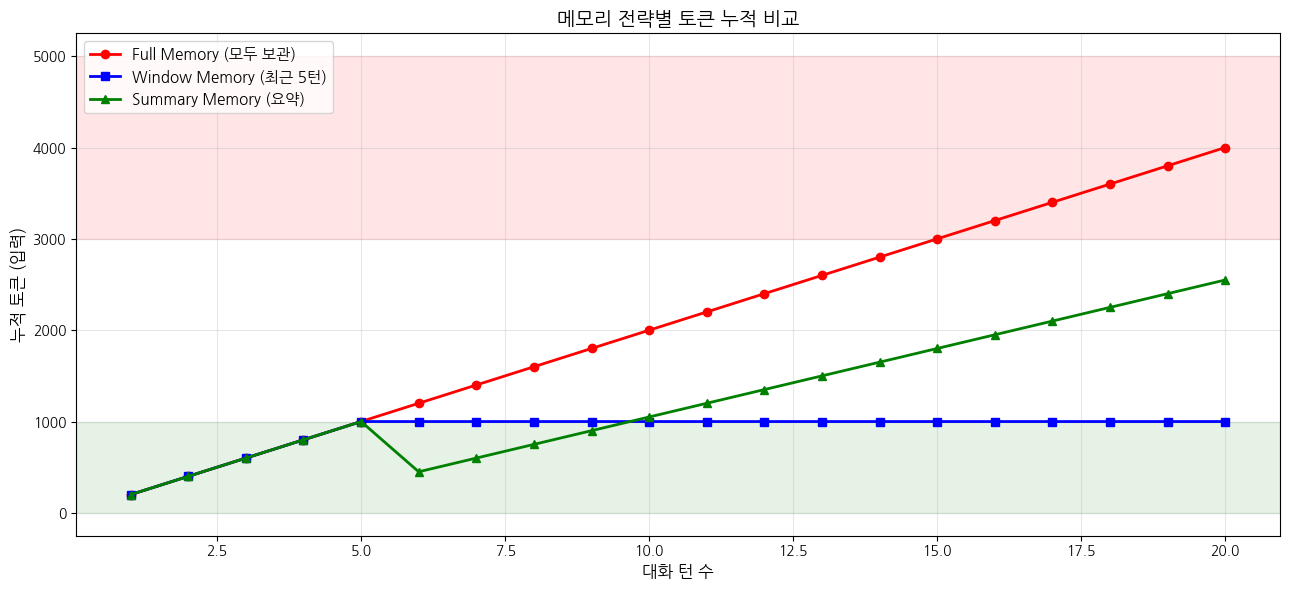


💡 긴 대화에서는 Window 또는 Summary Memory 권장!


In [23]:
# 🎨 메모리 전략 비교 시각화
fig, ax = plt.subplots(figsize=(13, 6))

n_turns = np.arange(1, 21)

# 1. Full Memory (모두 보관)
full_tokens = n_turns * 200  # 턴당 200토큰 누적

# 2. Window Memory (최근 5턴만)
window_tokens = np.minimum(n_turns, 5) * 200

# 3. Summary Memory (오래된 건 요약)
summary_tokens = np.where(n_turns > 5,
                            300 + (n_turns - 5) * 150,  # 요약 + 최근
                            n_turns * 200)

ax.plot(n_turns, full_tokens, 'o-', label='Full Memory (모두 보관)', color='red', linewidth=2)
ax.plot(n_turns, window_tokens, 's-', label='Window Memory (최근 5턴)', color='blue', linewidth=2)
ax.plot(n_turns, summary_tokens, '^-', label='Summary Memory (요약)', color='green', linewidth=2)

ax.set_xlabel('대화 턴 수', fontsize=12)
ax.set_ylabel('누적 토큰 (입력)', fontsize=12)
ax.set_title('메모리 전략별 토큰 누적 비교', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)

# 비용 영역 표시
ax.axhspan(0, 1000, alpha=0.1, color='green', label='저렴')
ax.axhspan(3000, 5000, alpha=0.1, color='red', label='비쌈')

plt.tight_layout()
plt.show()

print("\n💡 긴 대화에서는 Window 또는 Summary Memory 권장!")

---
# 🎓 최종 정리

## 🌟 우리가 배운 것

### 🧱 LangChain 핵심 구성 요소

| 컴포넌트 | 역할 | 학습 섹션 |
|---------|------|----------|
| **LLMs / Chat Models** | 모델 호출 | 1, 3 |
| **Prompts** | 프롬프트 템플릿화 | 4 |
| **Output Parsers** | 구조화된 출력 | 5 |
| **Runnables (LCEL)** | 체인 조립 | 3, 6 |
| **Memory** | 대화 기록 | 7 |
| **Document Loaders** | 문서 입력 | 8 |
| **Text Splitters** | 청크 분할 | 8 |
| **Embeddings** | 의미 벡터화 | 9 |
| **Vector Stores** | 의미 검색 | 9 |
| **Retrievers** | 검색 인터페이스 | 10 |
| **Tools** | 외부 함수 | 11 |
| **Agents** | 자율 에이전트 | 11 |

### 🔧 LCEL 패턴

```python
# 기본
chain = prompt | model | parser

# 병렬
parallel = RunnableParallel(a=chain1, b=chain2)

# 분기
branch = RunnableBranch(
    (condition1, chain1),
    (condition2, chain2),
    default_chain
)

# Pass-through
chain = (
    {"context": retriever | format, "question": RunnablePassthrough()}
    | prompt | model | parser
)
```

### 💼 실전 패턴 5가지

1. **챗봇** = Prompt + Memory + LLM
2. **RAG** = Retriever + Prompt + LLM
3. **대화형 RAG** = Memory + Retriever + Prompt + LLM
4. **Agent** = Tools + LLM + LangGraph
5. **하이브리드** = 의도 분류 → 분기 (RAG/Tool/일반)

## 🚀 다음 단계

### 📚 더 공부할 주제

#### 1️⃣ LangGraph (Agent의 진수)
- 상태 기반 워크플로우
- 인터럽트 (Human-in-the-loop)
- 복잡한 분기·반복 로직
- 멀티 에이전트 협업

#### 2️⃣ LangSmith (관측성)
- Chain 실행 추적
- 디버깅·평가
- 프로덕션 모니터링
- 무료 등급 제공!

#### 3️⃣ Advanced RAG
- Hybrid Search (의미 + 키워드)
- Re-ranking (cross-encoder)
- HyDE (Hypothetical Document Embeddings)
- Multi-vector retrieval

#### 4️⃣ Production 배포
- FastAPI + LangServe
- Docker + Kubernetes
- 캐싱 (Redis)
- 비용 모니터링

### 💡 실전 프로젝트 아이디어

#### 🥇 초급
- 📚 **PDF 챗봇**: 책 한 권을 RAG로
- 📰 **뉴스 요약 봇**: URL → 자동 요약
- 💬 **개인 메모리 챗봇**: 내 정보 기억

#### 🥈 중급
- 🏢 **회사 위키 챗봇**: Confluence/Notion + RAG
- 🛒 **상품 추천 시스템**: RAG + 사용자 선호
- 📊 **데이터 분석 비서**: Python REPL Tool

#### 🥉 고급
- 🤖 **자율 코딩 Agent**: GitHub + Tools
- 🌐 **다국어 고객 지원**: 의도 분류 + RAG + Translation
- 🎓 **AI 튜터**: 학생 진도 기억 + 맞춤 문제 출제

## 🏆 시리즈 9개 노트북 완성!

| 순서 | 노트북 | 핵심 |
|------|--------|------|
| 1 | Transformer | 🧠 모든 LLM의 기반 |
| 2 | BERT | 📖 텍스트 이해 |
| 3 | GPT | ✍️ 텍스트 생성 |
| 4 | VLM 전반 | 🌐 멀티모달 개요 |
| 5 | CLIP 깊이 | 🔗 매칭 마스터 |
| 6 | 생성형 VLM 깊이 | 💬 생성 마스터 |
| 7 | 시나리오 매트릭스 | 🎯 선택의 지혜 |
| 8 | 상업용 LLM 5종 | 🌐 API 활용 |
| 9 | **LangChain** | 🔗 **앱 빌딩** ✨ |

## 💡 마지막 조언

> 🎯 **"LangChain은 도구, 진짜 가치는 여러분이 만드는 앱입니다."**

### 🌟 LangChain을 잘 쓰는 5가지 원칙

1. **🧱 모듈화 우선**: 작은 부품 → 큰 시스템
2. **📊 측정하라**: 모든 응답을 평가 가능하게
3. **💰 비용을 의식하라**: 단순 작업엔 작은 모델
4. **🛡️ 견고하게 만들어라**: 에러·환각·재시도 처리
5. **📚 문서를 잘 읽어라**: LangChain은 빠르게 변함

### 🌐 추천 리소스

- 📖 **공식 문서**: https://python.langchain.com
- 🎓 **LangChain Academy**: https://academy.langchain.com (무료!)
- 💬 **Discord**: 활발한 커뮤니티
- 🐦 **Twitter**: @LangChainAI 팔로우

## 🙏 감사합니다!

긴 시리즈 여정을 함께해주셔서 감사합니다.

여러분은 이제 **AI 엔지니어로서의 완전한 도구상자**를 갖췄습니다:
- ✅ 핵심 이론 (Transformer/BERT/GPT/VLM)
- ✅ 실전 모델 사용 (API + 자체호스팅)  
- ✅ 모델 선택 안목
- ✅ **시스템 빌딩 능력 (LangChain)**

> "The best way to predict the future is to build it with AI."
>
> "AI의 미래를 예측하는 가장 좋은 방법은 직접 만드는 것이다."

**Happy Building! 🚀✨🔗**
